# Skenes vs Dominican WBC 2026 Hitters (2025 Regular Season)

This notebook summarizes how **Paul Skenes (694973)** fared against **Dominican Republic WBC 2026 hitters** during the **2025 MLB regular season**.

Use these tables and charts to take clean screenshots you can share with friends (e.g., in WhatsApp groups).

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve repo root whether this notebook is run from the root or from MLB/notebooks.
cwd = Path().resolve()
if (cwd / "MLB" / "outputs").exists():
    # Running from project root (Mallitalytics_VS)
    ROOT = cwd
elif cwd.name == "notebooks" and (cwd.parent.parent / "MLB" / "outputs").exists():
    # Running from MLB/notebooks → project root is two levels up
    ROOT = cwd.parent.parent
else:
    # Fallback: walk up until we find MLB/outputs
    ROOT = cwd
    for _ in range(5):
        if (ROOT / "MLB" / "outputs").exists():
            break
        ROOT = ROOT.parent

summary_path = ROOT / "MLB" / "outputs" / "pitching_matchups" / "skenes_vs_dr_2025_batter_summary.csv"
pitches_path = ROOT / "MLB" / "outputs" / "pitching_matchups" / "skenes_vs_dr_2025_pitch_by_pitch.csv"

df_summary = pd.read_csv(summary_path)
df_pitches = pd.read_csv(pitches_path)

df_summary

,batter,batter_name,PA,AB,H,HR,BB,SO,AVG,OBP
0,0,ALL_DR_HITTERS,26,23,1,0,3,7,0.043478,0.153846
1,467793,Carlos Santana,3,3,0,0,0,2,0.000000,0.000000
2,672695,Geraldo Perdomo,6,5,0,0,1,1,0.000000,0.166667
3,665161,Jeremy Peña,3,3,0,0,0,0,0.000000,0.000000
4,665742,Juan Soto,3,2,0,0,1,1,0.000000,0.333333
5,677594,Julio Rodríguez,3,3,1,0,0,2,0.333333,0.333333
6,691406,Junior Caminero,3,3,0,0,0,0,0.000000,0.000000
7,606466,Ketel Marte,3,2,0,0,1,0,0.000000,0.333333
8,665489,Vladimir Guerrero Jr.,2,2,0,0,0,1,0.000000,0.000000


## High-level vs DR WBC 2026 hitters

This table shows plate appearances (PA), at-bats (AB), hits (H), homers (HR), walks (BB), strikeouts (SO), batting average (AVG) and on-base percentage (OBP) for each Dominican WBC 2026 hitter vs Skenes, plus an overall line.

In [10]:
# Separate overall row and per-hitter rows
overall_row = df_summary[df_summary["batter_name"] == "ALL_DR_HITTERS"].copy()
hitters = df_summary[df_summary["batter_name"] != "ALL_DR_HITTERS"].copy()

# Sort hitters by PA (most faced first)
hitters = hitters.sort_values("PA", ascending=False)

# Format for a clean, WhatsApp-friendly screenshot
def fmt_rate(x):
    return f"{x:.3f}" if pd.notna(x) else ""

display_cols = ["batter_name", "PA", "AB", "H", "HR", "BB", "SO", "AVG", "OBP"]

hitters_fmt = hitters.copy()
hitters_fmt["AVG"] = hitters_fmt["AVG"].apply(fmt_rate)
hitters_fmt["OBP"] = hitters_fmt["OBP"].apply(fmt_rate)

overall_fmt = overall_row.copy()
overall_fmt["AVG"] = overall_fmt["AVG"].apply(fmt_rate)
overall_fmt["OBP"] = overall_fmt["OBP"].apply(fmt_rate)

full_table = pd.concat([hitters_fmt, overall_fmt], ignore_index=True)[display_cols]
full_table.rename(columns={"batter_name": "Batter"}, inplace=True)

print("Skenes vs Dominican WBC 2026 hitters (2025 regular season) — per-batter line + overall")
full_table

Skenes vs Dominican WBC 2026 hitters (2025 regular season) — per-batter line + overall


,Batter,PA,AB,H,HR,BB,SO,AVG,OBP
0,Geraldo Perdomo,6,5,0,0,1,1,0.000,0.167
1,Carlos Santana,3,3,0,0,0,2,0.000,0.000
2,Jeremy Peña,3,3,0,0,0,0,0.000,0.000
3,Juan Soto,3,2,0,0,1,1,0.000,0.333
4,Julio Rodríguez,3,3,1,0,0,2,0.333,0.333
5,Junior Caminero,3,3,0,0,0,0,0.000,0.000
6,Ketel Marte,3,2,0,0,1,0,0.000,0.333
7,Vladimir Guerrero Jr.,2,2,0,0,0,1,0.000,0.000
8,ALL_DR_HITTERS,26,23,1,0,3,7,0.043,0.154


## Per-hitter AVG & OBP vs Skenes

Bar chart of batting average and on-base percentage for each DR WBC hitter vs Skenes. This is ideal for a quick screenshot.

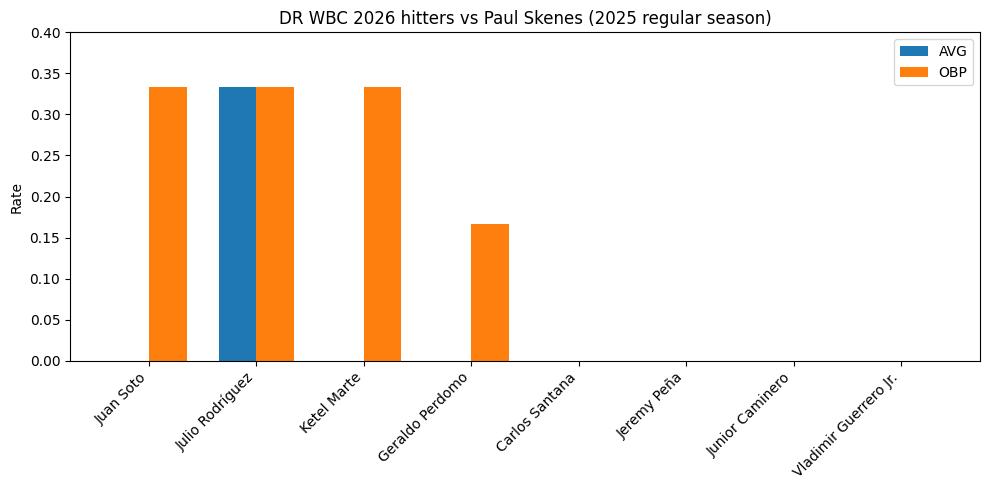

In [8]:
hitters_rates = hitters.copy()
hitters_rates = hitters_rates.sort_values("OBP", ascending=False)

names = hitters_rates["batter_name"].tolist()
x = range(len(names))
avg_vals = hitters_rates["AVG"].values
obp_vals = hitters_rates["OBP"].values

plt.figure(figsize=(10, 5))
width = 0.35
plt.bar([i - width/2 for i in x], avg_vals, width=width, label="AVG", color="#1f77b4")
plt.bar([i + width/2 for i in x], obp_vals, width=width, label="OBP", color="#ff7f0e")
plt.xticks(list(x), names, rotation=45, ha="right")
plt.ylabel("Rate")
plt.title("DR WBC 2026 hitters vs Paul Skenes (2025 regular season)")
plt.ylim(0, max(0.4, obp_vals.max() * 1.2))
plt.legend()
plt.tight_layout()
plt.show()

## Pitch mix vs DR WBC hitters

This chart shows Skenes' pitch-type usage against these hitters, which helps tell the story of how he attacked them.

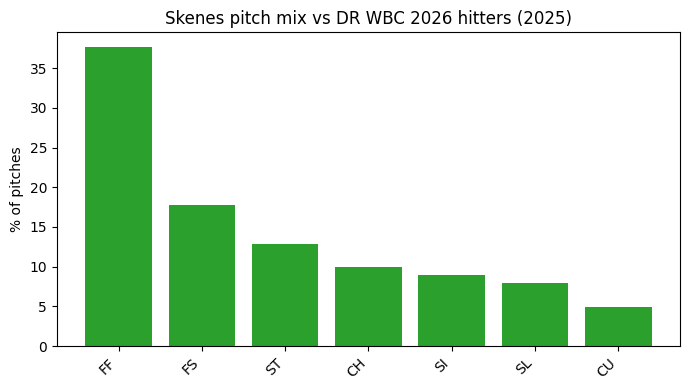

In [9]:
if not df_pitches.empty:
    pitch_counts = df_pitches["pitch_type"].value_counts().rename_axis("pitch_type").reset_index(name="count")
    pitch_counts["pct"] = pitch_counts["count"] / pitch_counts["count"].sum() * 100

    plt.figure(figsize=(7, 4))
    plt.bar(pitch_counts["pitch_type"], pitch_counts["pct"], color="#2ca02c")
    plt.ylabel("% of pitches")
    plt.title("Skenes pitch mix vs DR WBC 2026 hitters (2025)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No pitch-by-pitch data found for Skenes vs DR WBC hitters in 2025.")